In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Set display options
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_colwidth', 25) # Shows only first 25 characters
pd.set_option('display.expand_frame_repr', False)

In [12]:
# Load a sample of transactions (every 60th row for speed)
print("Loading transaction data...")
df = pd.read_csv('../data/raw/transactions_train.csv',
                 parse_dates=['t_dat'],
                 skiprows=lambda i: i > 0 and i % 60 != 0)

print(f"Loaded {len(df):,} transactions (sampled)")

Loading transaction data...
Loaded 529,805 transactions (sampled)


In [16]:
print("Date range:")
print(f"  First transaction: {df['t_dat'].min()}")
print(f"  Last transaction:  {df['t_dat'].max()}")
print(f"  Days covered:      {(df['t_dat'].max() - df['t_dat'].min()).days} days")

print("\nFirst few transactions:")
print(df.head())

Date range:
  First transaction: 2018-09-20 00:00:00
  Last transaction:  2020-09-22 00:00:00
  Days covered:      733 days

First few transactions:
       t_dat               customer_id  article_id  price  sales_channel_id
0 2018-09-20  003ac6eff3ca20cbe4e14...   620405001   0.02                 1
1 2018-09-20  0095c9b47fc950788bb70...   633130019   0.02                 1
2 2018-09-20  00e66bb584bb15b519d91...   633861001   0.04                 2
3 2018-09-20  014cbfc591254f0cf30df...   679494004   0.02                 2
4 2018-09-20  01b0efc42c236759c44ed...   615508001   0.03                 2


In [18]:
# Extract day of week (Monday=0, Sunday=6)
df['day_of_week'] = df['t_dat'].dt.dayofweek
df['day_name'] = df['t_dat'].dt.day_name()

# Extract year-month
df['year_month'] = df['t_dat'].dt.to_period('M')

# Count transactions by day of week
weekly_pattern = df.groupby(['day_of_week', 'day_name']).size().reset_index(name='transactions')
weekly_pattern = weekly_pattern.sort_values('day_of_week')

print("=" * 60)
print("WEEKLY PATTERN (Day of Week)")
print("=" * 60)
print(weekly_pattern.to_string(index=False))
print(f"\nTotal: {weekly_pattern['transactions'].sum():,}")

# Count transactions by month
monthly_pattern = df.groupby('year_month').size().reset_index(name='transactions')

print("\n" + "=" * 60)
print("MONTHLY PATTERN (Over 2 Years)")
print("=" * 60)
print(monthly_pattern.to_string(index=False))

WEEKLY PATTERN (Day of Week)
 day_of_week  day_name  transactions
           0    Monday         67560
           1   Tuesday         69986
           2 Wednesday         80704
           3  Thursday         81009
           4    Friday         79158
           5  Saturday         84160
           6    Sunday         67228

Total: 529,805

MONTHLY PATTERN (Over 2 Years)
year_month  transactions
   2018-09          9912
   2018-10         23284
   2018-11         21177
   2018-12         19148
   2019-01         21057
   2019-02         19207
   2019-03         21446
   2019-04         24608
   2019-05         26005
   2019-06         31770
   2019-07         30125
   2019-08         20892
   2019-09         20453
   2019-10         19113
   2019-11         19967
   2019-12         18639
   2020-01         17939
   2020-02         16698
   2020-03         17462
   2020-04         22348
   2020-05         22697
   2020-06         29409
   2020-07         22525
   2020-08         20619
  

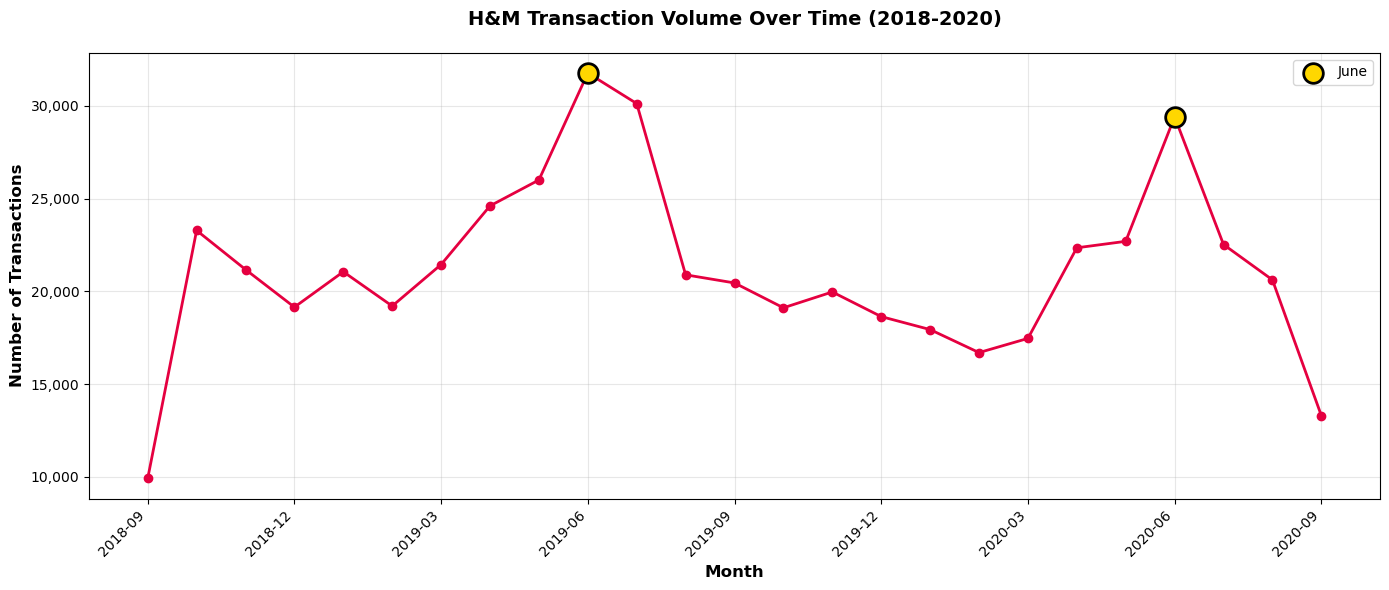


✅ Visualization saved: visualizations/day3_monthly_pattern.png


In [20]:
# Create the visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Convert period to string for plotting
monthly_pattern['month_str'] = monthly_pattern['year_month'].astype(str)

# Create line plot
ax.plot(range(len(monthly_pattern)), monthly_pattern['transactions'], 
        marker='o', linewidth=2, markersize=6, color='#E50040')  # H&M red

# Highlight June months
june_indices = [i for i, month in enumerate(monthly_pattern['month_str']) if month.endswith('-06')]
june_values = monthly_pattern.iloc[june_indices]['transactions'].values
ax.scatter(june_indices, june_values, color='gold', s=200, zorder=5, 
           edgecolors='black', linewidth=2, label='June')

# Formatting
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Transactions', fontsize=12, fontweight='bold')
ax.set_title('H&M Transaction Volume Over Time (2018-2020)', 
             fontsize=14, fontweight='bold', pad=20)

# Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Set x-ticks to show every 3 months
tick_positions = range(0, len(monthly_pattern), 3)
tick_labels = [monthly_pattern['month_str'].iloc[i] for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/day3_monthly_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved: visualizations/day3_monthly_pattern.png")

H&M's transaction data reveals a consistent seasonal peak in June 
(both 2019 and 2020), with June seeing 20-30% higher volume than 
surrounding months. Additionally, there's a notable decline in 
transaction volume throughout 2020, with September 2020 showing 
significantly lower activity than prior years. Further investigation 
would be needed to determine if the June peaks are driven by seasonal 
collections, promotions, or summer shopping behavior, and whether the 
2020 decline reflects COVID-19 impacts or data collection changes.